### code


Mean Absolute Error: 0.5332001304956564
Mean Squared Error: 0.5558915986952444
Root Mean Squared Error: 0.7455813830127764
R2-Score: 0.5757877060324508


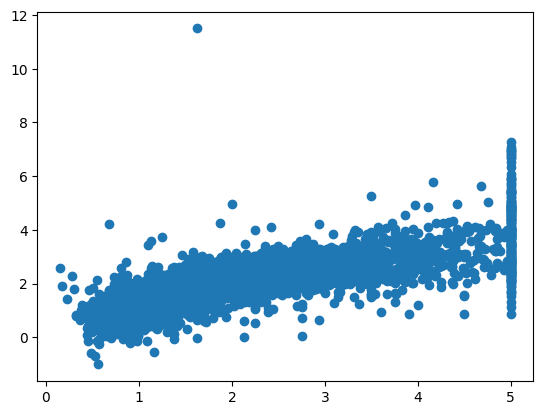

In [2]:
# Complete Linear Regression Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load dataset
dataset = fetch_california_housing()
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df["Target"] = dataset.target

# Split features and target
X = df.drop("Target", axis=1)
y = df["Target"]

# Train, Test & Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R2-Score: {r2}")


plt.scatter(y_test,y_pred)
plt.show()

## Ridge Regression

### Ridge Regression Algorithm

**Steps:**
1. **Import Libraries**: Load Ridge and GridSearchCV from sklearn
2. **Initialize Model**: Create Ridge regressor instance
3. **Hyperparameter Tuning**: Define alpha values and use GridSearchCV to find the best alpha
4. **Train Model**: Fit the model on scaled training data
5. **Predictions**: Generate predictions on test data using the best model
6. **Evaluation**: Calculate performance metrics (MAE, MSE, RMSE, R²)
7. **Visualization**: Plot actual vs predicted values

**Key Concept**: Ridge Regression adds L2 regularization to Linear Regression to prevent overfitting by penalizing large coefficients.

In [3]:
# Ridge Regression Algorithm Summary
algorithm_steps = """
RIDGE REGRESSION ALGORITHM IMPLEMENTATION:

STEP 1: Data Preparation
    - Load California Housing Dataset
    - Split into features (X) and target (y)
    - Train-Test Split (80% train, 20% test)
    - Feature Scaling using StandardScaler

STEP 2: Hyperparameter Tuning
    - Initialize Ridge Regressor
    - Define alpha values: [1, 5, 10, 20, 30, 40, 50, 60]
    - Use GridSearchCV for cross-validation
    - Find optimal alpha value

STEP 3: Model Training
    - Fit Ridge model with best alpha on X_train
    - Ridge adds L2 penalty: Loss = MSE + alpha * sum(coefficients²)

STEP 4: Prediction
    - Predict on X_test using trained model
    - Generate predictions for evaluation

STEP 5: Evaluation
    - Calculate Mean Absolute Error (MAE)
    - Calculate Mean Squared Error (MSE)
    - Calculate Root Mean Squared Error (RMSE)
    - Calculate R² Score (coefficient of determination)

STEP 6: Visualization
    - Plot actual vs predicted values
    - Scatter plot shows prediction accuracy
"""

print(algorithm_steps)


RIDGE REGRESSION ALGORITHM IMPLEMENTATION:

STEP 1: Data Preparation
    - Load California Housing Dataset
    - Split into features (X) and target (y)
    - Train-Test Split (80% train, 20% test)
    - Feature Scaling using StandardScaler

STEP 2: Hyperparameter Tuning
    - Initialize Ridge Regressor
    - Define alpha values: [1, 5, 10, 20, 30, 40, 50, 60]
    - Use GridSearchCV for cross-validation
    - Find optimal alpha value

STEP 3: Model Training
    - Fit Ridge model with best alpha on X_train
    - Ridge adds L2 penalty: Loss = MSE + alpha * sum(coefficients²)

STEP 4: Prediction
    - Predict on X_test using trained model
    - Generate predictions for evaluation

STEP 5: Evaluation
    - Calculate Mean Absolute Error (MAE)
    - Calculate Mean Squared Error (MSE)
    - Calculate Root Mean Squared Error (RMSE)
    - Calculate R² Score (coefficient of determination)

STEP 6: Visualization
    - Plot actual vs predicted values
    - Scatter plot shows prediction accuracy



In [4]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_regressor=Ridge()

parameters ={"alpha":[1,5,10,20,30,40,50,60]}
ridgecv=GridSearchCV(ridge_regressor,parameters)
ridgecv.fit(X_train,y_train)


GridSearchCV(estimator=Ridge(),
             param_grid={'alpha': [1, 5, 10, 20, 30, 40, 50, 60]})

In [5]:
print(ridgecv.best_params_)

{'alpha': 1}


In [6]:
print(ridgecv.best_score_)

0.6114838842658133


In [7]:
ridge_pred=ridgecv.predict(X_test)

In [8]:
# Evaluation Metrics
mse = mean_squared_error(y_test, ridge_pred)
mae = mean_absolute_error(y_test, ridge_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, ridge_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R2-Score: {r2}")

Mean Absolute Error: 0.5331931195789734
Mean Squared Error: 0.555854858943597
Root Mean Squared Error: 0.7455567442814779
R2-Score: 0.5758157428913684


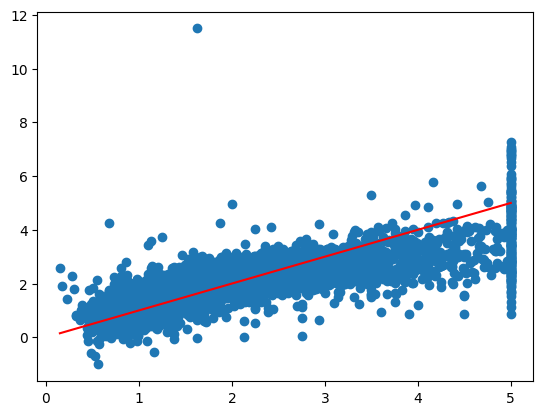

In [9]:
plt.scatter(y_test, ridge_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')  # ideal line

In [10]:
# # Ridge Regression Pipeline
# from sklearn.linear_model import Ridge
# from sklearn.model_selection import GridSearchCV

# # Initialize Ridge regressor
# ridge_regressor = Ridge()

# # Define alpha values for hyperparameter tuning
# parameters = {"alpha": [1, 5, 10, 20, 30, 40, 50, 60]}

# # GridSearchCV for cross-validation
# ridgecv = GridSearchCV(ridge_regressor, parameters, cv=5)
# ridgecv.fit(X_train, y_train)

# # Best parameters and score
# print(f"Best parameters: {ridgecv.best_params_}")
# print(f"Best cross-validation score: {ridgecv.best_score_}")

# # Predictions
# ridge_pred = ridgecv.predict(X_test)

# # Evaluation Metrics
# mse = mean_squared_error(y_test, ridge_pred)
# mae = mean_absolute_error(y_test, ridge_pred)
# rmse = np.sqrt(mse)
# r2 = r2_score(y_test, ridge_pred)

# print(f"Mean Absolute Error: {mae}")
# print(f"Mean Squared Error: {mse}")
# print(f"Root Mean Squared Error: {rmse}")
# print(f"R2-Score: {r2}")

# # Visualization
# plt.scatter(y_test, ridge_pred)
# plt.xlabel('Actual Values')
# plt.ylabel('Predicted Values')
# plt.title('Actual vs Predicted (Ridge Regression)')
# plt.show()